# **Part 1: Data Loading, Preprocessing and Initial Analysis**
This section focuses on loading the datasets necessary for the analysis, performing initial data cleaning/processing, and conducting a preliminary examination to understand the data structure and contents.



---





- Businesses pursue people who aim to lessen their consumption of advertisements, and are willing to pay their influencers more.

- Market Researchers find that influencer selection extends into product personality. This product and benefit matching is key. For a shampoo, it should use an influencer with good hair.


## **Data Loading & Preprocessing**

## Data Loading

In [53]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# loading the datasets
df_t=pd.read_csv('Data/social media influencers - tiktok.csv')
df_i=pd.read_csv('Data/social media influencers - instagram.csv')
df_y=pd.read_csv('Data/social media influencers - youtube.csv')

In [55]:
df_t.head(3)

,Tiktoker name,Tiktok name,Subscribers count,Views avg.,Likes avg,Comments avg.,Shares avg
0,ekin.721,MOMO’s,221.7K,26M,2.8M,29.4K,116.4K
1,dojacat,Doja Cat,22.2M,25.4M,5M,36.7K,46.8K
2,kiet.ac.quy,Kiệt Ắk Wỷ,2.1M,20.7M,3.5M,38.8K,33.9K



In tiktok dataset there is no category and audience related data,  so we didn't find it useful to tell a buisnessmen that which influencer must be approached by them category-wise.


### Data Cleaning & Preprocessing Function

In [56]:
# Function to convert String values to Numeric values

def convert(x):
    if isinstance(x, str):
        if 'K' in x:
            return float(x.replace('K', '')) * 1e3
        elif 'M' in x:
            return float(x.replace('M', '')) * 1e6
        else:
            # If there's no 'K' or 'M', but it's a string, we still try to convert to float
            return float(x)
    elif pd.isna(x):
        # If x is NaN (missing value), we return it as is, which can then be handled later
        return x
    else:
        return x

def change(df, list1):
    for col in list1:
        # Apply the convert function to each column in the list
        df['new_' + col] = df[col].apply(convert)

        # Replace NaNs with zeros if needed
        df['new_' + col] = df['new_' + col].fillna(0)

        df['new_' + col] = df['new_' + col].astype(float)
    return df


## TikTok Dataset Preprocessing

In [57]:
df_t.isnull().sum()

Tiktoker name        0
Tiktok name          2
Subscribers count    0
Views avg.           0
Likes avg            0
Comments avg.        0
Shares avg           0
dtype: int64

In [58]:
df_t['Subscribers count'].str[-1].value_counts()

Subscribers count
M    797
K    203
Name: count, dtype: int64

In [59]:
change(df_t,['Likes avg','Comments avg.', 'Views avg.', 'Shares avg', 'Subscribers count'])

,Tiktoker name,Tiktok name,Subscribers count,Views avg.,Likes avg,Comments avg.,Shares avg,new_Likes avg,new_Comments avg.,new_Views avg.,new_Shares avg,new_Subscribers count
0,ekin.721,MOMO’s,221.7K,26M,2.8M,29.4K,116.4K,2800000.0,29400.0,26000000.0,116400.0,221700.0
1,dojacat,Doja Cat,22.2M,25.4M,5M,36.7K,46.8K,5000000.0,36700.0,25400000.0,46800.0,22200000.0
2,kiet.ac.quy,Kiệt Ắk Wỷ,2.1M,20.7M,3.5M,38.8K,33.9K,3500000.0,38800.0,20700000.0,33900.0,2100000.0
3,charlidamelio,charli d’amelio,135.4M,18.7M,2.6M,54.7K,35.2K,2600000.0,54700.0,18700000.0,35200.0,135400000.0
4,luvadepedreiro,Iran Ferreira (Lai),11.4M,24.8M,2.6M,32.7K,26.8K,2600000.0,32700.0,24800000.0,26800.0,11400000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,nicolebernaal,nicolebernaal,4M,2.2M,351.3K,957,195,351300.0,957.0,2200000.0,195.0,4000000.0
996,bellaretamosa,bella,5.1M,2.5M,340.4K,901,145,340400.0,901.0,2500000.0,145.0,5100000.0
997,tunico80,🌠Antonio Tonon🌠,5.8M,1M,206.8K,2K,2.1K,206800.0,2000.0,1000000.0,2100.0,5800000.0
998,armon.warren,Armoney,1.2M,1.9M,300.8K,904,630,300800.0,904.0,1900000.0,630.0,1200000.0


### TOP 10 most followed celebrity on Tiktok as of 2022

In [60]:
df_t.sort_values(by='new_Subscribers count',ascending=False,ignore_index=True).iloc[0:10,[1,2]]

,Tiktok name,Subscribers count
0,charli d’amelio,135.4M
1,Khabane lame,135.2M
2,Bella Poarch,88.5M
3,Addison Rae,87.3M
4,Will Smith,67.4M
5,Kimberly Loaiza,61M
6,dixie,57.2M
7,Loren Gray,54.3M
8,Dominik,50.7M
9,Kris HC,43.3M


## Youtube and instagram data preprocessing

Renaming Few attributes for convenience

In [61]:
df_i.rename({'category_1':'Category','Audience country(mostly)':'Audience Country'},axis=1,inplace=True)

In [62]:
df_i.isnull().sum()

Influencer insta name         0
instagram name               21
Category                    108
category_2                  713
Followers                     0
Audience Country             14
Authentic engagement\r\n      0
Engagement avg\r\n            0
dtype: int64

In [63]:
df_y.isnull().sum()

youtuber name         0
channel name          0
Category            277
Subscribers           0
Audience Country    161
avg views             0
avg likes            38
avg comments        209
dtype: int64

In [64]:
df_i.drop(labels=['Influencer insta name','Authentic engagement\r\n'],axis=1,inplace=True)
df_i.shape

(1000, 6)

In [65]:
change(df_i,['Followers','Engagement avg\r\n'])
change(df_y,['avg likes','avg views', 'avg comments', 'Subscribers'])

,youtuber name,channel name,Category,Subscribers,Audience Country,avg views,avg likes,avg comments,new_avg likes,new_avg views,new_avg comments,new_Subscribers
0,tseries,T-Series,Music & Dance,212.1M,India,323.7K,9.8K,290,9800.0,323700.0,290.0,212100000.0
1,checkgate,Cocomelon - Nursery Rhymes,Education,132.1M,NaN,13.8M,80.9K,NaN,80900.0,13800000.0,0.0,132100000.0
2,setindia,SET India,NaN,130.4M,India,23.6K,314,21,314.0,23600.0,21.0,130400000.0
3,PewDiePie,PewDiePie,Animation,111.4M,United States,1.4M,80.8K,4.6K,80800.0,1400000.0,4600.0,111400000.0
4,MrBeast6000,MrBeast,Video games,92.5M,United States,30.6M,1.7M,67.7K,1700000.0,30600000.0,67700.0,92500000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,FutParódias,FutParódias,Music & Dance,9.2M,Brazil,1.4M,110.1K,2.5K,110100.0,1400000.0,2500.0,9200000.0
996,EL GATO,EL GATO,Toys,9.2M,Brazil,243.8K,30.7K,636,30700.0,243800.0,636.0,9200000.0
997,CinemaSins,CinemaSins,Movies,9.2M,United States,296K,10.2K,874,10200.0,296000.0,874.0,9200000.0
998,CricketICC,ICC,Sports,9.2M,India,15.2K,854,58,854.0,15200.0,58.0,9200000.0




---



## **Engagement rate**
The Percentage of Followers who really engages with the content posted by Influencers
<br/>

### Why ER  is so Important?
1. Good ER means your content is making an impact on audience(they really  like you)
2.  The higher the engagement ,the more likely it is that the content will be boosted in the newsfeed and attracting more eyes.

##### Engagement Rate formula:
    ER=(Engagement Average/total Followers)*100

In [66]:
# Feature Engineering: Creating additional features that may be useful for recommendations

# TikTok: Create an 'engagement rate' feature (engagement per post divided by subscribers)
df_t['Engagement Rate'] = ((df_t['new_Likes avg'] + df_t['new_Comments avg.'] + df_t['new_Shares avg']) / df_t['new_Subscribers count']) * 100

# Instagram: Calculate engagement rate similarly
df_i['Engagement Rate'] = ((df_i['new_Engagement avg\r\n']  / df_i['new_Followers']) * 100)

# YouTube: Also create an engagement rate
df_y['Engagement Rate'] = ((df_y['new_avg likes'] + df_y['new_avg views'] + df_y['new_avg comments']) / df_y['new_Subscribers']) * 100

df_t.head(), df_i.head(), df_y.head()


(    Tiktoker name          Tiktok name Subscribers count Views avg. Likes avg  \
 0        ekin.721               MOMO’s            221.7K        26M      2.8M   
 1         dojacat             Doja Cat             22.2M      25.4M        5M   
 2     kiet.ac.quy           Kiệt Ắk Wỷ              2.1M      20.7M      3.5M   
 3   charlidamelio      charli d’amelio            135.4M      18.7M      2.6M   
 4  luvadepedreiro  Iran Ferreira (Lai)             11.4M      24.8M      2.6M   
 
   Comments avg. Shares avg  new_Likes avg  new_Comments avg.  new_Views avg.  \
 0         29.4K     116.4K      2800000.0            29400.0      26000000.0   
 1         36.7K      46.8K      5000000.0            36700.0      25400000.0   
 2         38.8K      33.9K      3500000.0            38800.0      20700000.0   
 3         54.7K      35.2K      2600000.0            54700.0      18700000.0   
 4         32.7K      26.8K      2600000.0            32700.0      24800000.0   
 
    new_Shares avg

# **Part 2: Detailed Analysis by Platform**
This section delves deeper into specific analyses for different social media platforms like TikTok, YouTube, and Instagram, exploring engagement metrics, audience characteristics, and content popularity.


---




## Defining some analytical Functions required for later use

In [67]:
pallete = ['#86BBD8', '#4AADD6', '#0099CC', '#0077B6', '#005E9D', '#FFB6C1', '#FF69B4', '#FF1493', '#D81B60', '#89023E']

from matplotlib.colors import LinearSegmentedColormap

def plot(df):
    plt.figure(figsize=(10,6))
    plt.xlabel('number of times category occured')
    plt.ylabel('Category')
    df['Category'].value_counts().sort_values(ascending=True).plot.barh(color=pallete)

## TikTok Analysis
We start our detailed platform analysis with TikTok, focusing on popular categories and the relationship between various metrics like views, likes, and subscriber counts.


#### 1. What is the relationship between the average number of views and engagement metrics like likes, comments, and shares for TikTok influencers?

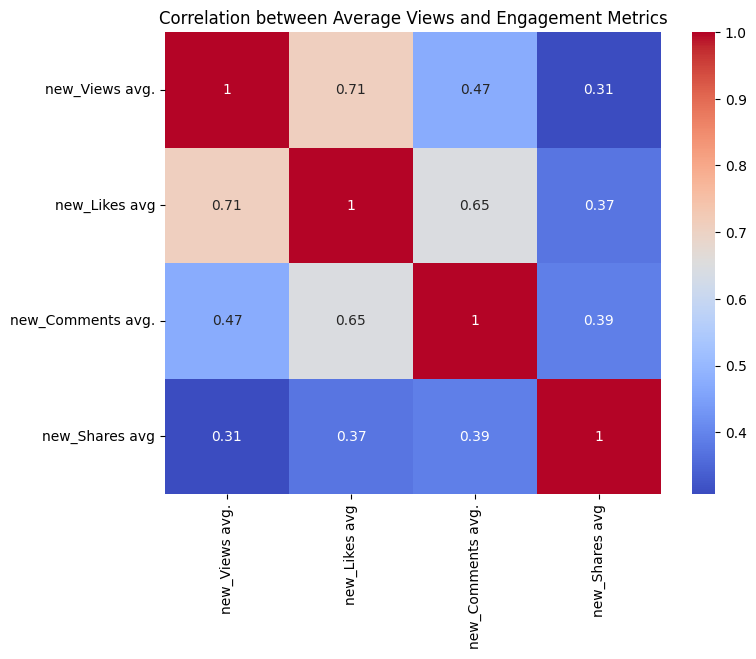

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df_t[['new_Views avg.', 'new_Likes avg', 'new_Comments avg.', 'new_Shares avg']].corr()

# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Average Views and Engagement Metrics')
plt.show()


#### 2. How does content popularity (measured by average views) vary with subscriber count on TikTok?

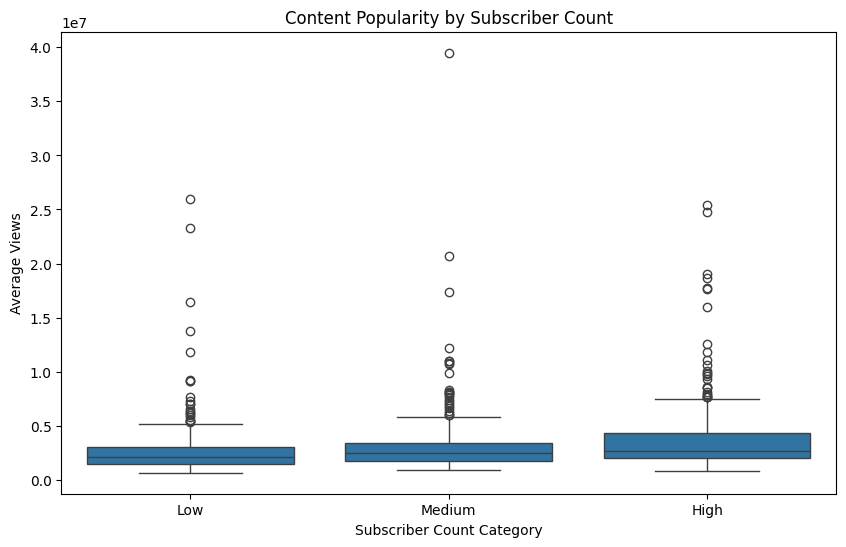

In [69]:
# Visualizing how average views vary with subscriber counts
df_t['subscriber_category'] = pd.qcut(df_t['new_Subscribers count'], q=3, labels=['Low', 'Medium', 'High'])

# Boxplot to show distribution of views across subscriber categories
plt.figure(figsize=(10, 6))
sns.boxplot(x='subscriber_category', y='new_Views avg.', data=df_t)
plt.title('Content Popularity by Subscriber Count')
plt.xlabel('Subscriber Count Category')
plt.ylabel('Average Views')
plt.show()


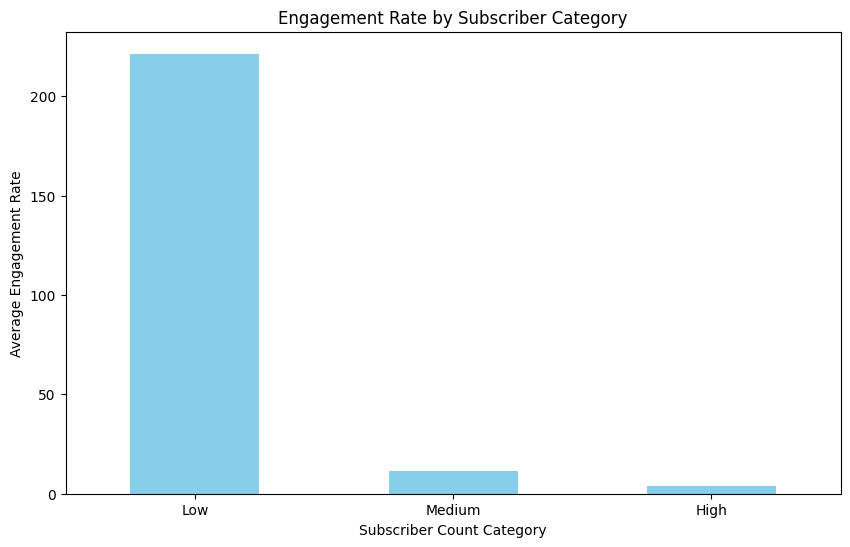

In [70]:
# Grouping by subscriber categories and calculating mean engagement rates
engagement_by_subscriber = df_t.groupby('subscriber_category')['Engagement Rate'].mean()

# Plotting engagement rates across subscriber categories
plt.figure(figsize=(10, 6))
engagement_by_subscriber.plot(kind='bar', color='skyblue')
plt.title('Engagement Rate by Subscriber Category')
plt.xlabel('Subscriber Count Category')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=0)
plt.show()


### 3. What patterns can be identified in engagement rates (likes, comments, shares) across different subscriber levels on TikTok?

1. High Subscriber Counts Don’t Necessarily Equate to High Engagement Rates: It seems that influencers with a smaller subscriber base have higher engagement rates. This can happen when an influencer has a more niche but engaged audience.

2. Diminishing Engagement With Scale: As subscriber counts increase, the engagement rate appears to decrease. This could be due to a variety of factors, such as broader but less engaged audiences or the challenges of maintaining high engagement at scale.

3. Potential for Anomalies: The engagement rate is an average, so influencers who have extremely high likes, comments, or shares on a relatively smaller number of views can significantly skew this metric upwards.

## Youtube Analysis
Continuing with YouTube, we analyze content categories, audience engagement, and the correlation between subscriber counts and average views to uncover patterns that could guide content strategy.

Top 10 most Followed Channels on Youtube as of 2022


,channel name,Category,Subscribers
0,T-Series,Music & Dance,212.1M
1,Cocomelon - Nursery Rhymes,Education,132.1M
2,SET India,NaN,130.4M
3,PewDiePie,Animation,111.4M
4,MrBeast,Video games,92.5M
5,✿ Kids Diana Show,Animation,92.4M
6,Like Nastya,Animation,90.1M
7,WWE,Video games,86.9M
8,Zee Music Company,Music & Dance,82.7M
9,Vlad and Niki,Toys,80.4M


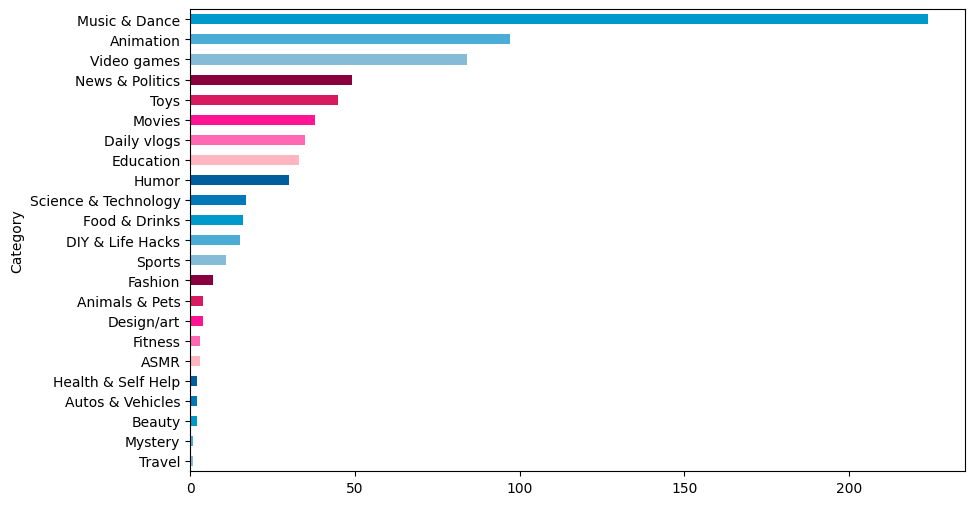

In [71]:
plot(df_y)
print("Top 10 most Followed Channels on Youtube as of 2022")
df_y.iloc[0:10,[1,2,3]]

#### 1. Content Categories and Audience Engagement

To analyze how different content categories affect audience engagement, you can group the data by category and calculate aggregate metrics for views, likes, and comments.

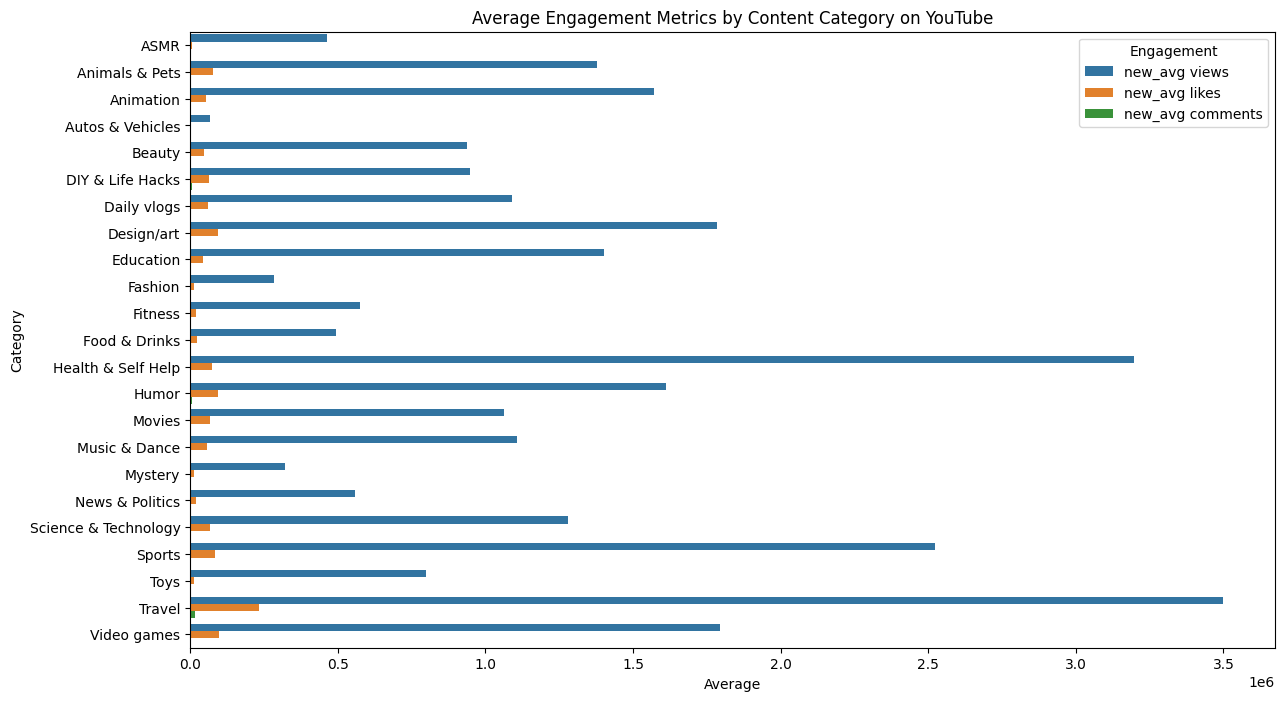

In [72]:
engagement_by_category = df_y.groupby('Category').agg({
    'new_avg views': 'mean',
    'new_avg likes': 'mean',
    'new_avg comments': 'mean'
}).reset_index()

# Melt the DataFrame for easier plotting
engagement_melted = pd.melt(engagement_by_category, id_vars='Category', var_name='Engagement', value_name='Average')

# Plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Average', y='Category', hue='Engagement', data=engagement_melted)
plt.title('Average Engagement Metrics by Content Category on YouTube')
plt.show()

#### 2. Correlation Between Subscriber Count and Average Views

Calculate the correlation between subscriber count and average views using a scatter plot and correlation coefficient.

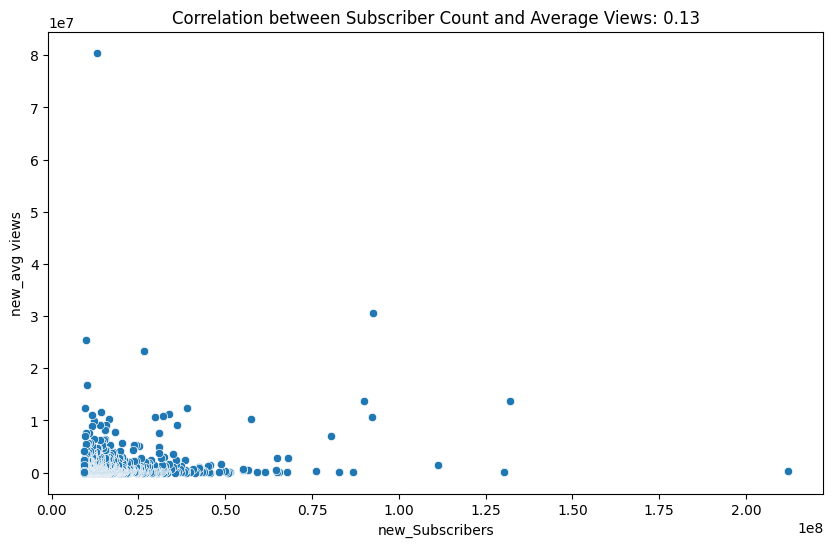

In [73]:
# Calculate correlation coefficient
correlation = df_y['new_Subscribers'].corr(df_y['new_avg views'])

# Plot scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='new_Subscribers', y='new_avg views', data=df_y)
plt.title(f'Correlation between Subscriber Count and Average Views: {correlation:.2f}')
plt.show()


#### 3. Audience Country and Engagement Metrics

To explore how audience country influences engagement metrics, you would perform an analysis similar to the content category, but group by the audience's country.

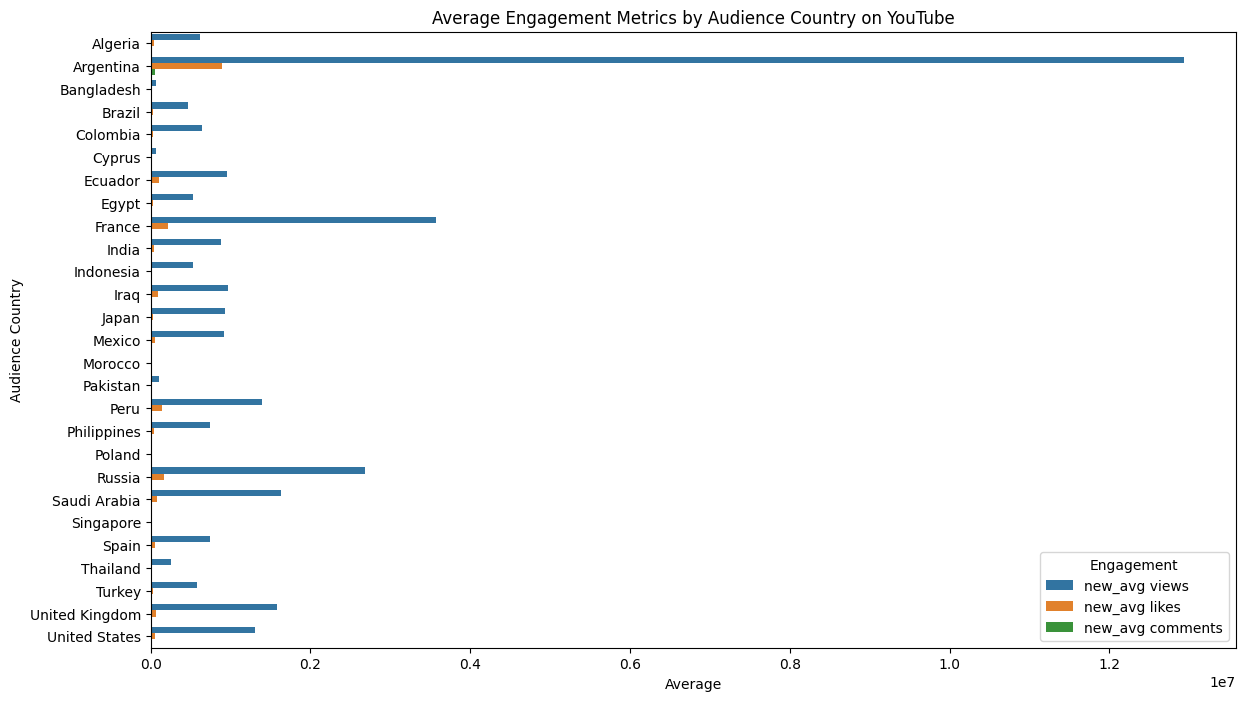

In [74]:
# Group by 'Audience Country' and calculate mean for 'views', 'likes', and 'comments'
engagement_by_country = df_y.groupby('Audience Country').agg({
    'new_avg views': 'mean',
    'new_avg likes': 'mean',
    'new_avg comments': 'mean'
}).reset_index()

# Melt the DataFrame for easier plotting
engagement_country_melted = pd.melt(engagement_by_country, id_vars='Audience Country', var_name='Engagement', value_name='Average')

# Plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Average', y='Audience Country', hue='Engagement', data=engagement_country_melted)
plt.title('Average Engagement Metrics by Audience Country on YouTube')
plt.show()

#### 4. Characteristics of Most Engaged YouTube Videos

Identify videos with high engagement and analyze their characteristics such as category.

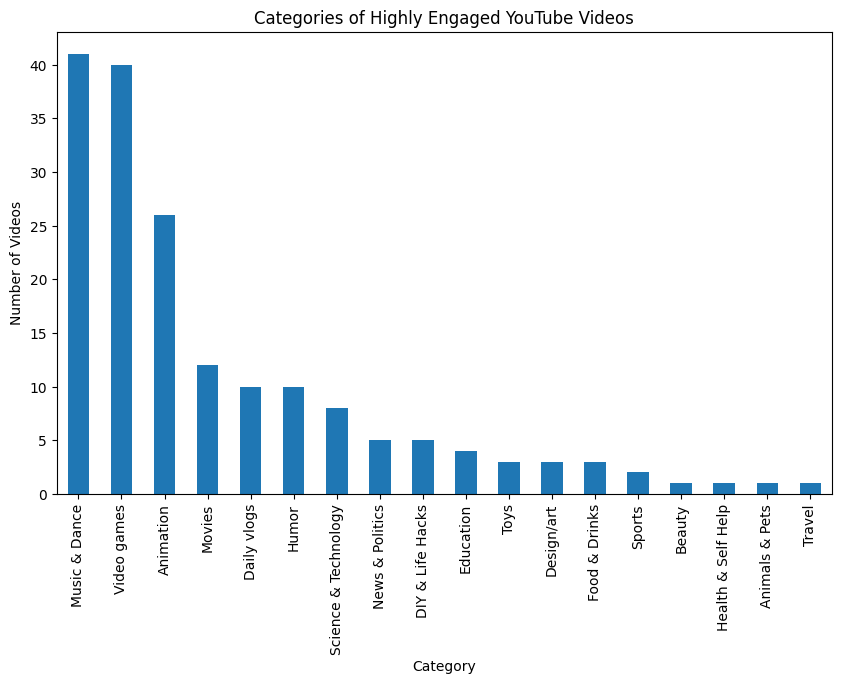

In [75]:
# Define a threshold for high engagement (you might use a quantile, mean, etc.)
high_engagement_threshold = df_y[['new_avg likes', 'new_avg comments']].quantile(0.75)

# Filter videos with high engagement
high_engagement_videos = df_y[
    (df_y['new_avg likes'] >= high_engagement_threshold['new_avg likes']) &
    (df_y['new_avg comments'] >= high_engagement_threshold['new_avg comments'])
]

# Analyze the characteristics of these videos
most_engaged_categories = high_engagement_videos['Category'].value_counts()

plt.figure(figsize=(10, 6))
most_engaged_categories.plot(kind='bar')
plt.title('Categories of Highly Engaged YouTube Videos')
plt.ylabel('Number of Videos')
plt.show()

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

# 2. Determine the Threshold
# We'll label the top 25% of engagement scores as 'beneficial for marketing' (1) and the rest as not (0)
threshold = df_y['Engagement Rate'].quantile(0.75)
df_y['target'] = np.where(df_y['Engagement Rate'] >= threshold, 1, 0)

# 3. Prepare the Data
# Select features and target
features = ['new_Subscribers', 'new_avg views', 'new_avg likes', 'new_avg comments']  # Add more as needed
X = pd.get_dummies(df_y[features + ['Category']], drop_first=True)  # Convert 'Category' into dummy variables
y = df_y['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train a Logistic Regression Model
model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed for convergence
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Accuracy: 1.0


## Instagram Analysis
Finally Instagram, let's investigate how follower counts correlate with engagement metrics, the impact of content categories, and engagement levels across different countries.

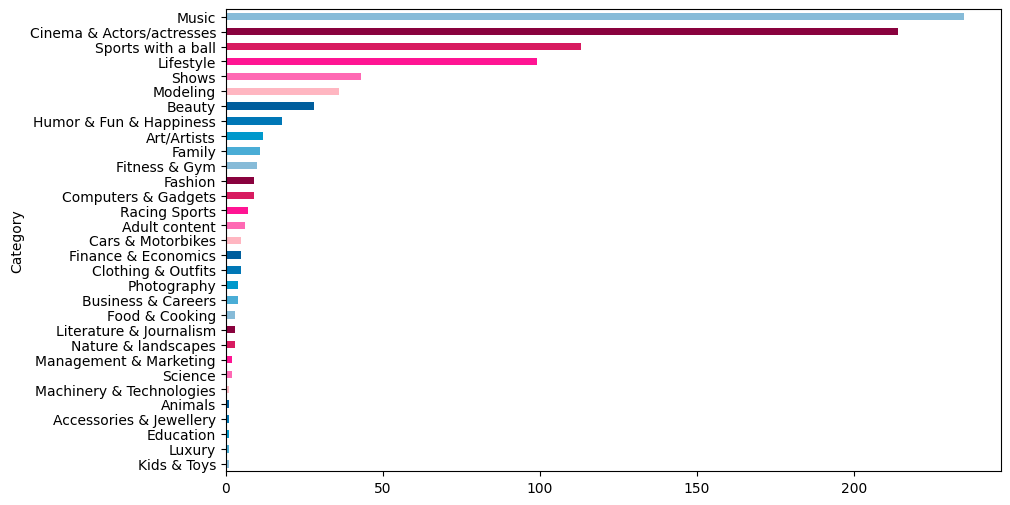

In [77]:
# Plot Showing most popular Categories on Instagram
plot(df_i)

#### 1. Follower Count Correlation with Engagement Metrics

To explore the relationship between follower count and engagement metrics, you can calculate the correlation coefficient and create a scatter plot.

) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


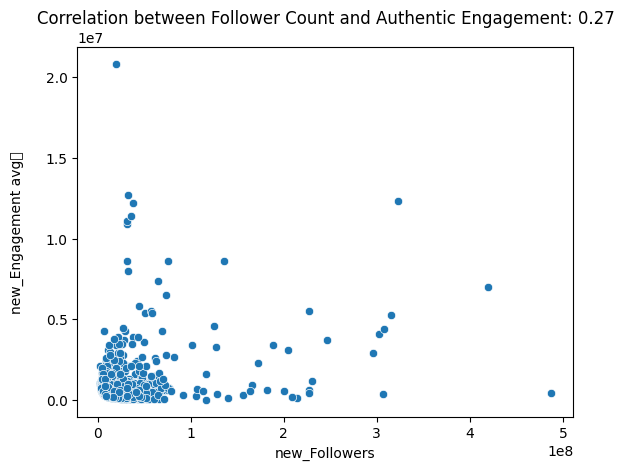

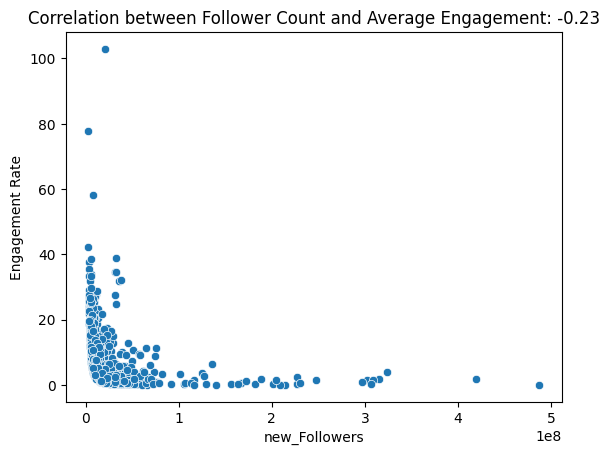

In [78]:
# Calculate correlation coefficients
correlation_authentic_engagement = df_i['new_Followers'].corr(df_i['new_Engagement avg\r\n'])
correlation_average_engagement = df_i['new_Followers'].corr(df_i['Engagement Rate'])

# Plot scatter plots
sns.scatterplot(x='new_Followers', y='new_Engagement avg\r\n', data=df_i)
plt.title(f'Correlation between Follower Count and Authentic Engagement: {correlation_authentic_engagement:.2f}')
plt.show()

sns.scatterplot(x='new_Followers', y='Engagement Rate', data=df_i)
plt.title(f'Correlation between Follower Count and Average Engagement: {correlation_average_engagement:.2f}')
plt.show()

#### 2. Impact of Content Categories on Engagement


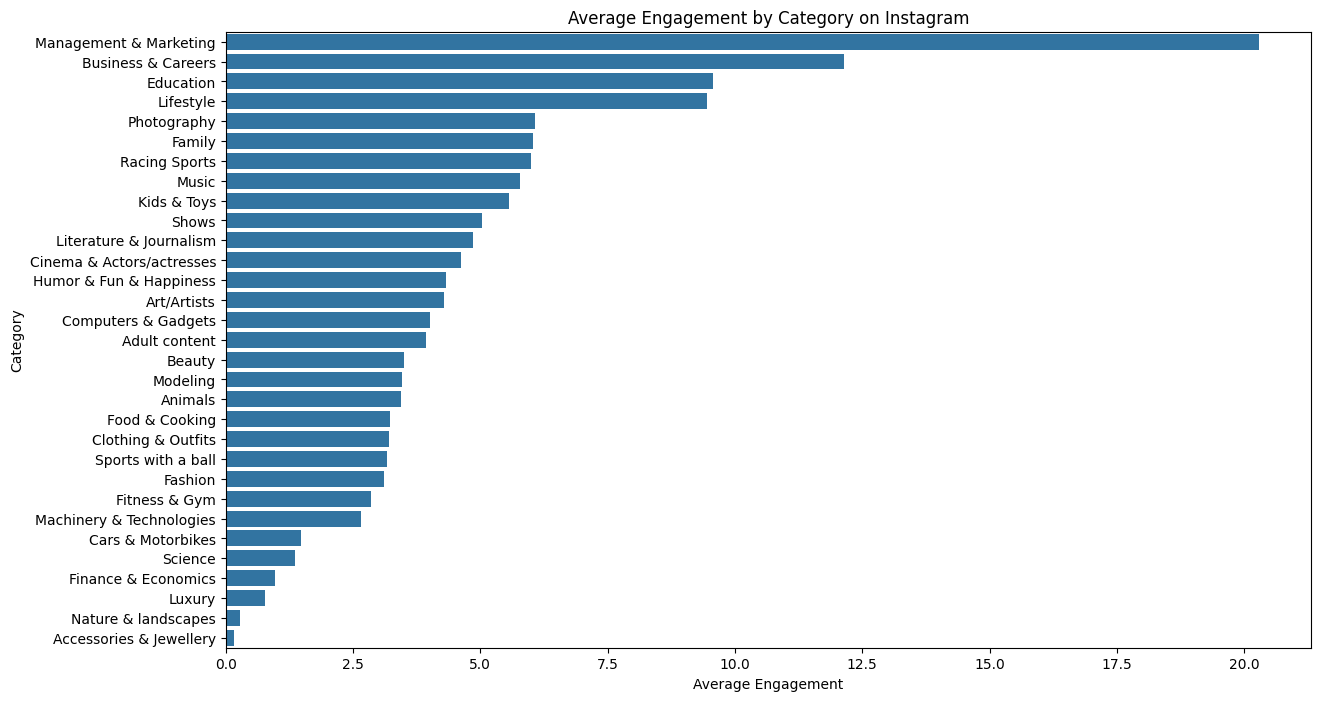

In [79]:
# Group by 'Category' to find its impact on engagement
engagement_by_category = df_i.groupby('Category').agg({
    'Engagement Rate': 'mean'
}).reset_index().sort_values(by='Engagement Rate', ascending=False)

# Bar plot for average engagement by category
plt.figure(figsize=(14, 8))
sns.barplot(x='Engagement Rate', y='Category', data=engagement_by_category)
plt.title('Average Engagement by Category on Instagram')
plt.xlabel('Average Engagement')
plt.ylabel('Category')
plt.show()

#### 3. Audience Country and Engagement Levels

Group by audience country and calculate average engagement metrics to understand the impact of audience location on engagement levels.

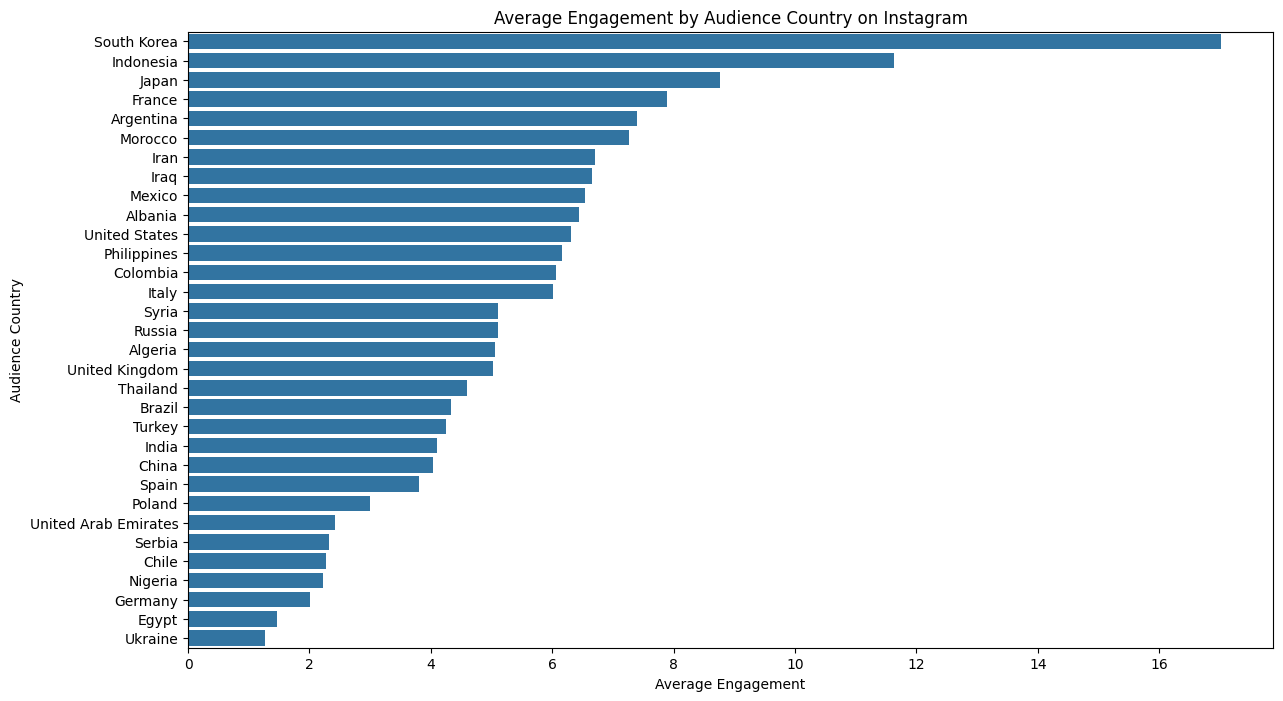

In [80]:
# Group by 'Audience Country' and calculate mean for 'new_Engagement avg\r\n' and 'Engagement Rate'
engagement_by_country = df_i.groupby('Audience Country').agg({
    'Engagement Rate': 'mean'
}).reset_index().sort_values(by='Engagement Rate', ascending=False)

# Visualize this information with bar plots
plt.figure(figsize=(14, 8))
sns.barplot(x='Engagement Rate', y='Audience Country', data=engagement_by_country)
plt.title('Average Engagement by Audience Country on Instagram')
plt.xlabel('Average Engagement')
plt.ylabel('Audience Country')
plt.show()

#### 4. Engagement Patterns for Different Categories

To observe engagement patterns across different influencer categories, you can use visualization techniques to plot the distribution of engagement rates across categories.

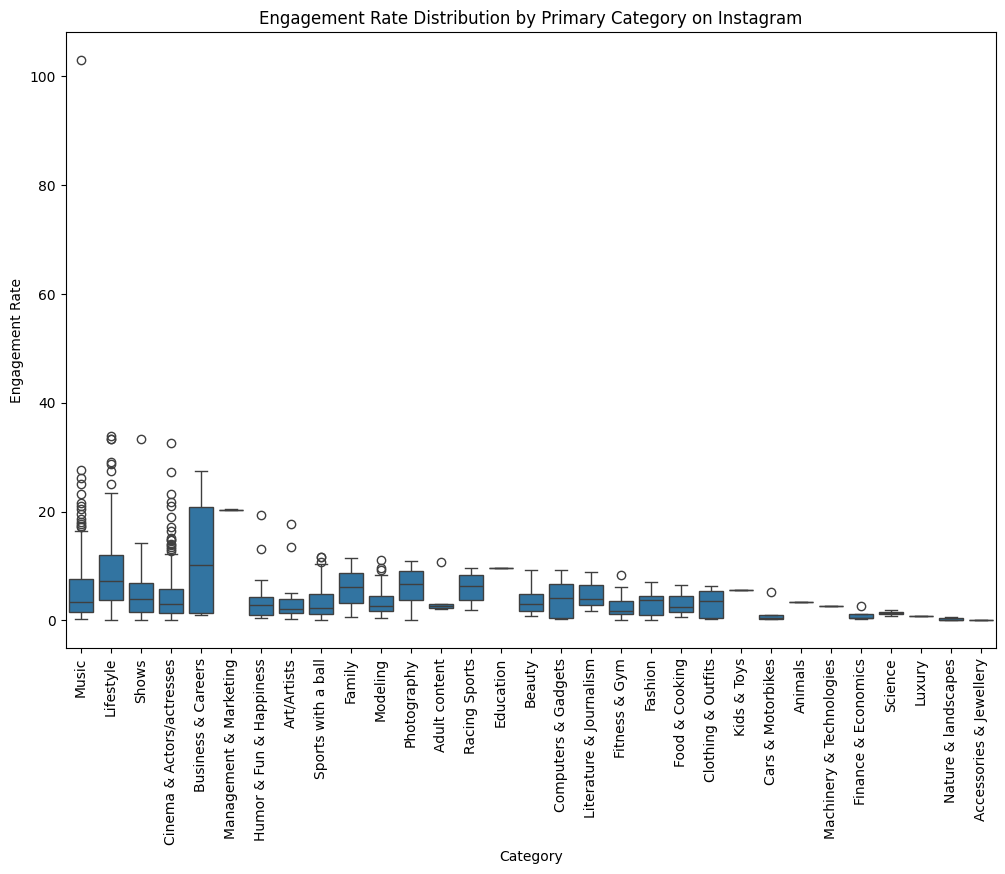

In [81]:
# For each category, plot the distribution of 'Engagement Rate'
plt.figure(figsize=(12, 8))
sns.boxplot(x='Category', y='Engagement Rate', data=df_i.sort_values(by='Engagement Rate', ascending=False))
plt.title('Engagement Rate Distribution by Primary Category on Instagram')
plt.xticks(rotation=90)
plt.show()


#### 5. Fake Instagram Profile Detection using neural network
The number of followers, the ratio of followers to following, the age of the account, the activity level (e.g., number of posts, comments, likes), the kinds of content posted, the use of hashtags, the presence of a profile picture and biography, and the use of third-party apps to boost activity are important characteristics that can be used as input features for a fake account detection model in influencer marketing. A machine learning model can be trained to differentiate between real and fake accounts by examining these characteristics, which would enable marketers to choose influencers for their campaigns with more knowledge.

##### Data Preprocessing

In [97]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.models import Sequential
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,accuracy_score,roc_curve,confusion_matrix
from sklearn.metrics import confusion_matrix

In [83]:
# Load the training dataset
instagram_df_train=pd.read_csv('Data/train.csv')
instagram_df_train

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.00,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.00,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.00,0,0,0,1,13,159,98,0
3,1,0.00,1,0.00,0,82,0,0,679,414,651,0
4,1,0.00,2,0.00,0,0,0,1,6,151,126,0
...,...,...,...,...,...,...,...,...,...,...,...,...
571,1,0.55,1,0.44,0,0,0,0,33,166,596,1
572,1,0.38,1,0.33,0,21,0,0,44,66,75,1
573,1,0.57,2,0.00,0,0,0,0,4,96,339,1
574,1,0.57,1,0.00,0,11,0,0,0,57,73,1


In [84]:
# Load the testing data
instagram_df_test=pd.read_csv('Data/test.csv')
instagram_df_test

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.33,1,0.33,1,30,0,1,35,488,604,0
1,1,0.00,5,0.00,0,64,0,1,3,35,6,0
2,1,0.00,2,0.00,0,82,0,1,319,328,668,0
3,1,0.00,1,0.00,0,143,0,1,273,14890,7369,0
4,1,0.50,1,0.00,0,76,0,1,6,225,356,0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,1,0.29,1,0.00,0,0,0,0,13,114,811,1
116,1,0.40,1,0.00,0,0,0,0,4,150,164,1
117,1,0.00,2,0.00,0,0,0,0,3,833,3572,1
118,0,0.17,1,0.00,0,0,0,0,1,219,1695,1


##### Statistical Analysis

In [85]:
# Getting dataframe info
instagram_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


In [86]:
# Get the number of unique values in the "profile pic" feature
instagram_df_train['profile pic'].value_counts()

profile pic
1    404
0    172
Name: count, dtype: int64

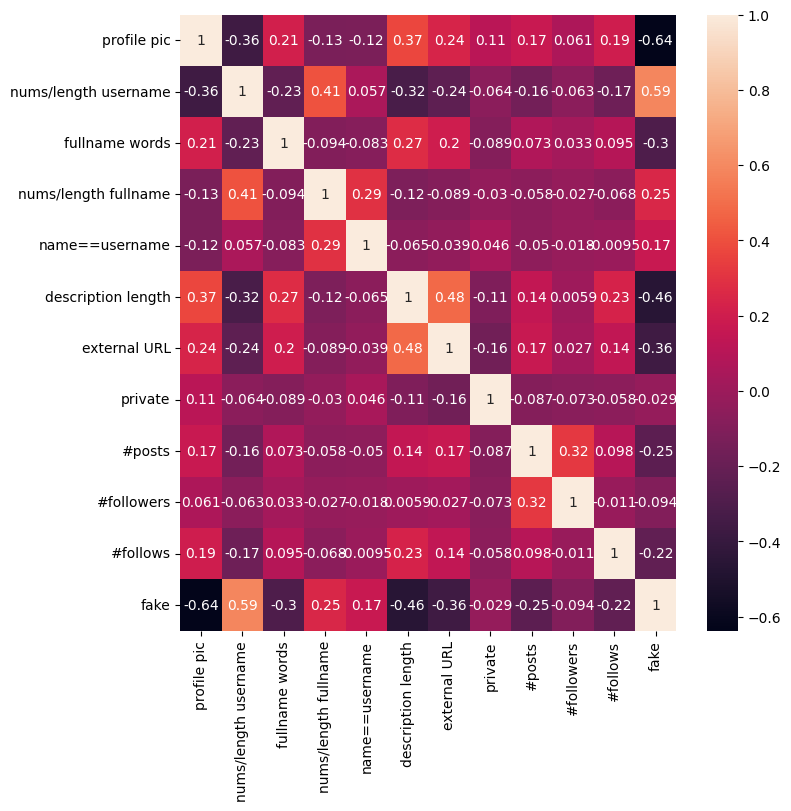

In [87]:
# Correlation plot
plt.figure(figsize=(8, 8))
cm = instagram_df_train.corr()
ax = plt.subplot()
sns.heatmap(cm, annot = True, ax = ax)
plt.show()

##### Data Modeling

In [149]:
# Training and testing dataset (inputs)
# X_train = instagram_df_train.drop(columns = ['fake'])
# X_test = instagram_df_test.drop(columns = ['fake'])
# X_train

scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(instagram_df_train.drop(columns=['fake']))
X_test = scaler_x.transform(instagram_df_test.drop(columns=['fake']))
y_train = instagram_df_train['fake']
y_test = instagram_df_test['fake']

##### KNN model

In [131]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train_scaled and X_test_scaled are your scaled feature sets
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, instagram_df_train['fake'])

# Predict the labels for the test set
y_pred = knn.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(instagram_df_test['fake'], y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8833333333333333


##### NN model

In [106]:
# Scale the data before training the model
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

In [107]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes = 2)
y_test = tf.keras.utils.to_categorical(y_test, num_classes = 2)

In [108]:
y_train

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

In [109]:
model = Sequential()
model.add(Dense(50, input_dim=11, activation='relu'))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(150, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(25, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2,activation='softmax'))

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 50)                600       
                                                                 
 dense_16 (Dense)            (None, 150)               7650      
                                                                 
 dropout_9 (Dropout)         (None, 150)               0         
                                                                 
 dense_17 (Dense)            (None, 150)               22650     
                                                                 
 dropout_10 (Dropout)        (None, 150)               0         
                                                                 
 dense_18 (Dense)            (None, 25)                3775      
                                                                 
 dropout_11 (Dropout)        (None, 25)               

In [110]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [111]:
epochs_hist = model.fit(X_train, y_train, epochs = 50,  verbose = 1, validation_split = 0.1)

Epoch 1/50
17/17 [==============================] - 2s 19ms/step - loss: 0.5874 - accuracy: 0.7181 - val_loss: 0.4177 - val_accuracy: 0.7759
Epoch 2/50
17/17 [==============================] - 0s 8ms/step - loss: 0.3797 - accuracy: 0.8571 - val_loss: 0.1730 - val_accuracy: 0.8966
Epoch 3/50
17/17 [==============================] - 0s 8ms/step - loss: 0.2909 - accuracy: 0.8880 - val_loss: 0.2326 - val_accuracy: 0.8793
Epoch 4/50
17/17 [==============================] - 0s 8ms/step - loss: 0.2872 - accuracy: 0.8977 - val_loss: 0.1885 - val_accuracy: 0.8793
Epoch 5/50
17/17 [==============================] - 0s 8ms/step - loss: 0.2732 - accuracy: 0.9093 - val_loss: 0.1977 - val_accuracy: 0.8966
Epoch 6/50
17/17 [==============================] - 0s 8ms/step - loss: 0.2586 - accuracy: 0.9093 - val_loss: 0.1547 - val_accuracy: 0.8966
Epoch 7/50
17/17 [==============================] - 0s 8ms/step - loss: 0.2387 - accuracy: 0.9073 - val_loss: 0.1783 - val_accuracy: 0.8966
Epoch 8/50
17/17 [=

##### Model Validation and Results

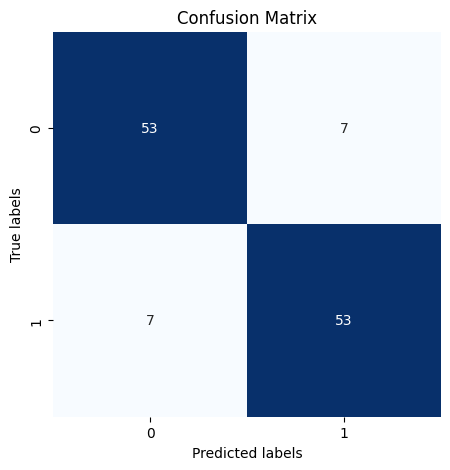

In [148]:
# KNN confusion matrix
# Calculate the confusion matrix
cm_ = confusion_matrix(instagram_df_test['fake'], y_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(cm_, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

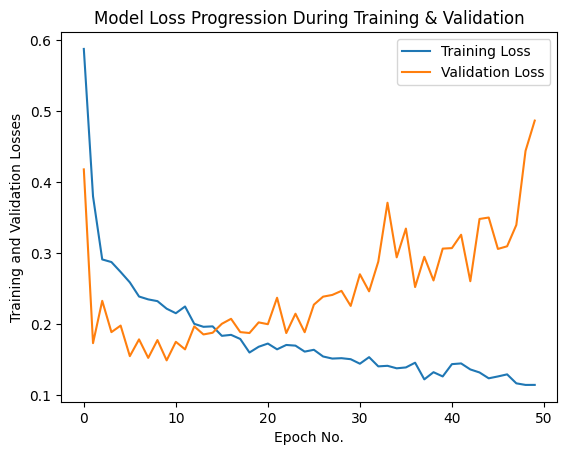

In [147]:
plt.plot(epochs_hist.history['loss'])
plt.plot(epochs_hist.history['val_loss'])

plt.title('Model Loss Progression During Training & Validation')
plt.ylabel('Training and Validation Losses')
plt.xlabel('Epoch No.')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

In [140]:
predicted = model.predict(X_test)
predicted_value = []
test = []
for i in predicted:
    predicted_value.append(np.argmax(i))

for i in y_test:
    test.append(np.argmax(i))

4/4 [==============================] - 0s 8ms/step


In [141]:
print(classification_report(test, predicted_value))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89        60
           1       0.90      0.87      0.88        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120



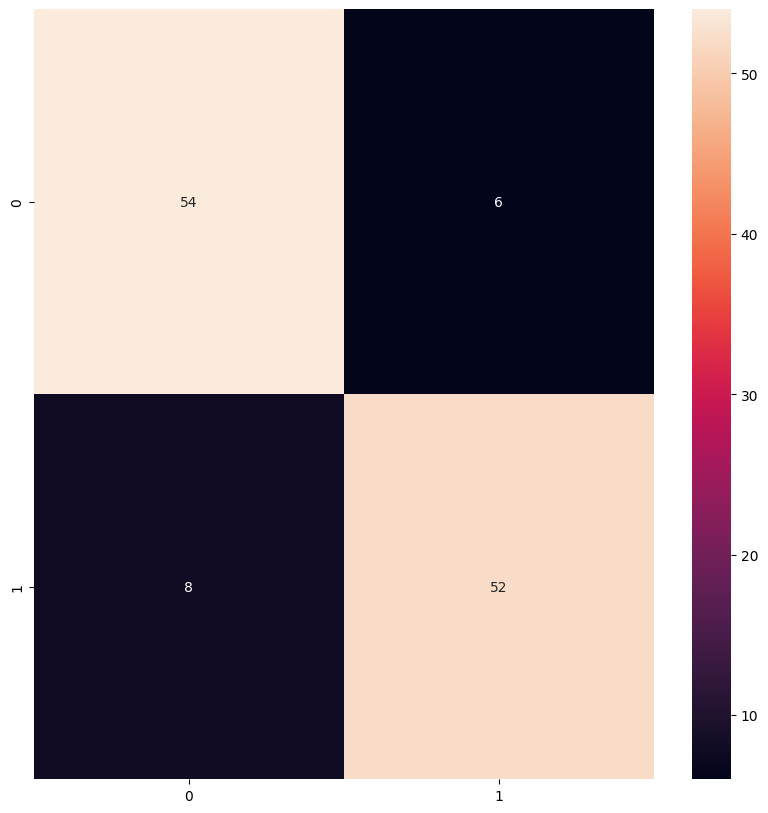

In [145]:
# NN confusion matrix

plt.figure(figsize=(10, 10))
cm=confusion_matrix(test, predicted_value)
sns.heatmap(cm, annot=True)
plt.show()

# **Part 3: Strategic Ad Placement Analysis**
This section aims to guide a company's decision-making on where to place ads, focusing on identifying the demand for different product categories country-wise and leveraging influencer engagement metrics to maximize ad impact.


## Country and Category Demand Analysis
Analyze the demand for various product categories in different countries to identify potential markets for targeted advertisements.


### If a company wants to decide where they want to make ads (country), we check the demand for categories Country wise

### For understanding where is the demand of product

In [ ]:
def demand(data,category):
    return data[data['Category']==category]['Audience Country'].value_counts().sort_values(ascending=True).plot.barh(color=pallete)

In [ ]:
demand(df_y,'Education')

In [ ]:
demand(df_i,'Lifestyle')



1. **Targeting by Category and Country**
   When selecting a country for advertisement placement, it is essential to choose one where there is significant interest in the particular category being promoted. This ensures that the advertising efforts reach a receptive and large audience.

   For instance, if a company wants to advertise an educational app, India could be an ideal target due to the high engagement with educational content among its audience. This strategic choice maximizes the likelihood of the advertisement resonating with potential users.

2. **Cross-Platform Category Variability**
   It is important to note that not all product categories are present on both platforms, and their popularity can vary significantly between them.

3. **Platform-Specific Popularity**
   Certain categories may experience varying levels of popularity depending on the platform. For example, categories like Education and Animation are more popular on YouTube than on Instagram. This insight is crucial for directing advertising resources to the platforms where they will have the most impact.

   Specifically, categories such as Education and Animation are more effectively engaged with on YouTube compared to Instagram, suggesting a strategic focus on YouTube for these categories to achieve better advertising outcomes.


## Visualize and compare the distribution of the audience's countries across your dataset


In [ ]:
# def plot_c(df):
#     plt.figure(figsize=(10,8))
#     plt.xlabel('number of times category occured')
#     df['Audience Country'].value_counts().sort_values().plot.barh(color=pallete)

In [ ]:
def plot_c(df, top_n=30):
    colors = sns.color_palette("husl", top_n)

    country_counts = df['Audience Country'].value_counts().tail(top_n).sort_values(ascending=True)

    plt.figure(figsize=(12, 9))
    bars = plt.barh(country_counts.index, country_counts.values, color=colors)

    for bar in bars:
        plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f' {int(bar.get_width())}',
                 va='center', ha='left', color='black', fontsize=8)

    plt.xlabel('Number of times country occurred')
    plt.title('Top ' + str(top_n) + ' Audience Countries on Instagram')
    plt.tight_layout()
    plt.show()

In [ ]:
plot_c(df_y)

## Detailed Influencer Analysis
Based on the analysis, provide recommendations for choosing countries and influencer types (mini or mega influencers) for advertising different product categories on various social media platforms.

### if you  want to make ads by mini or mega influencers for instagram

In [ ]:
df_i['new_Followers'].describe()

In [ ]:
df_i['new_Followers'].quantile(0.40)

 Taking 10M as a threshold means for instagram celebrity havning above 10M followers are considerd to be mega celebrity or large scale Influencer

In [ ]:
def for_mini_followers_instagram(coun,cat):
    df1=df_i[df_i['Audience Country']==coun]
    df1_mini=df1[df1['new_Followers'] < 10000000]        # Filtering Influencers who have less than 10 million followers
    return df1_mini.sort_values(by='Engagement Rate',ascending=False).groupby('Category').get_group(cat).iloc[:,[0,3,-1]]

def for_mega_followers_instagram(coun,cat):
    df1=df_i[df_i['Audience Country']==coun]
    df1_mini=df1[df1['new_Followers'] > 10000000]         # Filtering Influencers who have more than 10 million followers
    return df1_mini.sort_values(by='Engagement Rate',ascending=False).groupby('Category').get_group(cat).iloc[:,[0,3,-1]]

In [ ]:
for_mini_followers_instagram('United States','Music')

In [ ]:
for_mega_followers_instagram('India','Music')

In [ ]:
for_mini_followers_instagram('India','Beauty')

In [ ]:
for_mini_followers_instagram('India','Shows')

In [ ]:
for_mini_followers_instagram('India','Sports with a ball')

In [ ]:
for_mega_followers_instagram('India','Sports with a ball')

### if you want to make ads by mini or mega influencers for youtube


In [ ]:
df_y['new_Subscribers'].describe()

In [ ]:
df_y['new_Subscribers'].quantile(0.40)

In [ ]:
def for_mini_followers_youtube(coun,cat):
    df1=df_y[df_y['Audience Country']==coun]
    df1_mini=df1[df1['new_Subscribers']<=10000000]
    return df1_mini.sort_values(by='Engagement Rate',ascending=False).groupby('Category').get_group(cat).iloc[:,[0,3,-1]]

def for_mega_followers_youtube(coun,cat):
    df1=df_y[df_y['Audience Country']==coun]
    df1_mini=df1[df1['new_Subscribers']>300000]
    return df1_mini.sort_values(by='Engagement Rate',ascending=False).groupby('Category').get_group(cat).iloc[:,[0,3,-1]]

In [ ]:
for_mini_followers_youtube('United States','Music & Dance')

In [ ]:
for_mega_followers_youtube('Brazil','Sports')

In [ ]:
for_mega_followers_youtube('India','Movies')

In [ ]:
df_y[df_y['Audience Country']=='Spain']['Category'].value_counts()

In [ ]:
df_y[df_y['Audience Country']=='Brazil']['Category'].value_counts()

In [ ]:
df_y['Category'].value_counts()